# HAM10000 Dataset Exploration

Get familiar with HAM10000 before writing the prepare script. The goal is to understand:
- Class distribution (heavily imbalanced)
- Multiple images per lesion (motivates lesion-grouped train/val/test splits)
- Demographics, diagnosis confidence, image quality, color statistics

Run cells top to bottom. Add your own cells at the end to dig further.

## 1. Setup

In [108]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Walk up from cwd until we find the project root.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "ml" / "data" / "raw" / "ham10000").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError("Could not find project root (looking for ml/data/raw/ham10000)")
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "ml" / "data" / "raw" / "ham10000"
META_PATH = RAW_DIR / "HAM10000_metadata.csv"
IMG_DIRS = [RAW_DIR / "HAM10000_images_part_1", RAW_DIR / "HAM10000_images_part_2"]

print(f"Project root: {PROJECT_ROOT}")
print(f"Metadata:     {META_PATH}")

Project root: c:\Users\alpas\Desktop\CLEAR
Metadata:     c:\Users\alpas\Desktop\CLEAR\ml\data\raw\ham10000\HAM10000_metadata.csv


## 2. Load metadata

In [109]:
meta = pd.read_csv(META_PATH)
print("Shape:", meta.shape)
print("\nDtypes:")
print(meta.dtypes)
meta.head()

Shape: (10015, 7)

Dtypes:
lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
dtype: object


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 3. Glossary: `dx` codes and `dx_type`

### `dx` — diagnosis code (the label)

| code | full name | meaning | Phase 1 binary group |
|------|-----------|---------|----------------------|
| `mel` | melanoma | Malignant skin cancer originating in melanocytes; the most dangerous of the seven | suspicious |
| `nv` | melanocytic nevus | Common mole; nearly always benign | non_suspicious |
| `bcc` | basal cell carcinoma | Most common skin cancer; rarely spreads but should be removed | suspicious |
| `akiec` | actinic keratosis / intraepithelial carcinoma | Pre-cancerous; can progress to squamous cell carcinoma if untreated | suspicious |
| `bkl` | benign keratosis | Catch-all for benign keratosis-like lesions (solar lentigo, seborrheic keratosis, lichen planus-like) | non_suspicious |
| `df` | dermatofibroma | Benign fibrous nodule, often on the legs | non_suspicious |
| `vasc` | vascular lesion | Blood-vessel lesions: angiomas, angiokeratomas, hemorrhages | non_suspicious |

Phase 1 binary mapping (from `ml/data/README.md` Rule 5):
- **suspicious** = `mel`, `bcc`, `akiec`
- **non_suspicious** = `nv`, `bkl`, `df`, `vasc`

### `dx_type` — how the diagnosis was confirmed

| code | meaning | reliability |
|------|---------|-------------|
| `histo` | Histopathology — biopsy and lab analysis | Highest; ground truth |
| `follow_up` | Lesion observed clinically over time and didn't change → assumed benign | Medium; only valid for benign cases |
| `consensus` | Multiple experts agreed from clinical/dermoscopic images alone | Medium |
| `confocal` | In-vivo confocal microscopy (non-invasive imaging) | Medium-high |

Note: `dx_type` describes how the *diagnosis* was confirmed, not how the *image* was captured. All HAM10000 images are dermatoscopy photos regardless of `dx_type`.

When evaluating model performance later, take per-class metrics with `dx_type` distribution in mind: a model that does well on `histo`-confirmed cases is more trustworthy than one that does well on `follow_up`-only cases.

## 4. Class distribution

HAM10000 is heavily imbalanced. The model will see lots of `nv` (common moles) and very few `df` (dermatofibroma) or `vasc` (vascular lesions). This will matter when we evaluate per-class metrics later.

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Total: 10015
Most common: nv = 66.9%


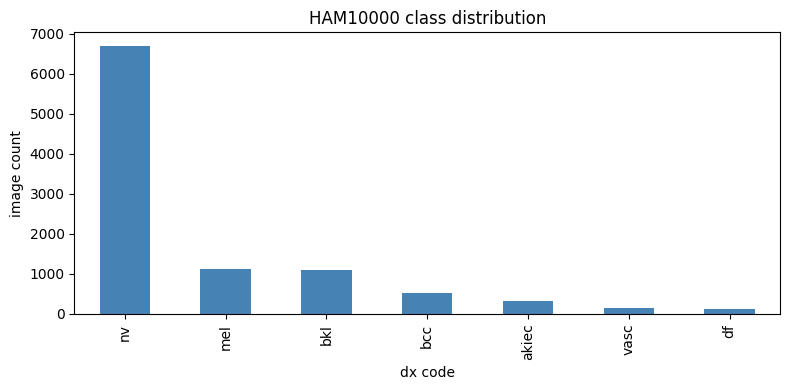

In [110]:
counts = meta["dx"].value_counts()
print(counts)
print(f"\nTotal: {counts.sum()}")
print(f"Most common: {counts.index[0]} = {counts.iloc[0] / counts.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("HAM10000 class distribution")
ax.set_xlabel("dx code")
ax.set_ylabel("image count")
plt.tight_layout()
plt.show()

## 5. Multiple images per lesion

**Important:** HAM10000 has multiple images of the same lesion (different angles, lighting, etc.) — they share a `lesion_id` but have different `image_id`s.

If we split images randomly into train/val/test, the same lesion could appear in both train and test. The model would memorize specific lesions instead of learning patterns, and test accuracy would be inflated.

The fix is to split at the **lesion** level: all images of one lesion go to one split. This cell shows why it matters.

Distribution of images-per-lesion:
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64

Unique lesions: 7470
Total images:   10015
Lesions with >1 image: 1956


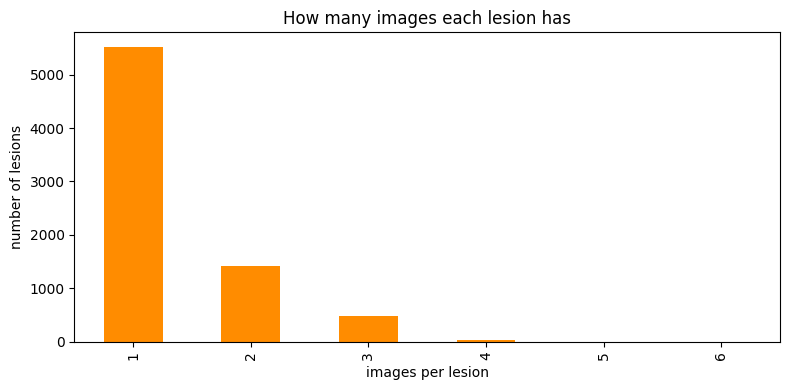

In [111]:
images_per_lesion = meta.groupby("lesion_id").size()
print("Distribution of images-per-lesion:")
print(images_per_lesion.value_counts().sort_index())
print(f"\nUnique lesions: {meta['lesion_id'].nunique()}")
print(f"Total images:   {len(meta)}")
print(f"Lesions with >1 image: {(images_per_lesion > 1).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
images_per_lesion.value_counts().sort_index().plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("How many images each lesion has")
ax.set_xlabel("images per lesion")
ax.set_ylabel("number of lesions")
plt.tight_layout()
plt.show()

## 6. Lesion-level invariants

If `lesion_id` truly identifies one physical skin spot, then several columns should be constant within each lesion: `localization` (it's the same spot), `dx` (same diagnosis), and `sex` (same patient). `age` may vary across visits, so we expect that to differ.

Verify this is true in the data — if any non-age column has multiple unique values for some lesion, it's a data quality issue we'd need to handle.

In [112]:
def lesion_invariant_violations(col: str) -> int:
    """Number of lesions where this column has more than one unique value."""
    return int((meta.groupby("lesion_id")[col].nunique() > 1).sum())

total_lesions = meta["lesion_id"].nunique()
print(f"Total unique lesions: {total_lesions}")
print("\nLesions where this column has more than one unique value:")
print(f"  localization: {lesion_invariant_violations('localization')}  (expected 0 — same physical spot)")
print(f"  dx:           {lesion_invariant_violations('dx')}  (expected 0 — same diagnosis)")
print(f"  sex:          {lesion_invariant_violations('sex')}  (expected 0 — same patient)")
print(f"  age:          {lesion_invariant_violations('age')}  (may be nonzero — different visits)")

Total unique lesions: 7470

Lesions where this column has more than one unique value:
  localization: 2  (expected 0 — same physical spot)
  dx:           0  (expected 0 — same diagnosis)
  sex:          0  (expected 0 — same patient)
  age:          0  (may be nonzero — different visits)


### 6.1 Drill into localization mismatches

If section 6 reported any localization violations, this cell shows the actual rows so you can judge whether they're data-entry mistakes or something meaningful (e.g., adjacent lesions miscoded under one `lesion_id`).

In [113]:
mismatch_mask = meta.groupby("lesion_id")["localization"].nunique() > 1
violators = mismatch_mask[mismatch_mask].index.tolist()
print(f"Lesions with multiple localizations: {len(violators)}\n")

cols = ["lesion_id", "image_id", "dx", "dx_type", "localization", "age", "sex"]
violators_df = meta[meta["lesion_id"].isin(violators)][cols].sort_values(["lesion_id", "image_id"])
violators_df

Lesions with multiple localizations: 2



,lesion_id,image_id,dx,dx_type,localization,age,sex
1211,HAM_0000871,ISIC_0025964,mel,histo,chest,40.0,female
2014,HAM_0000871,ISIC_0026506,mel,histo,trunk,40.0,female
1212,HAM_0000871,ISIC_0030623,mel,histo,chest,40.0,female
1248,HAM_0001726,ISIC_0024367,mel,histo,back,35.0,female
2008,HAM_0001726,ISIC_0024700,mel,histo,trunk,35.0,female
1247,HAM_0001726,ISIC_0029281,mel,histo,back,35.0,female


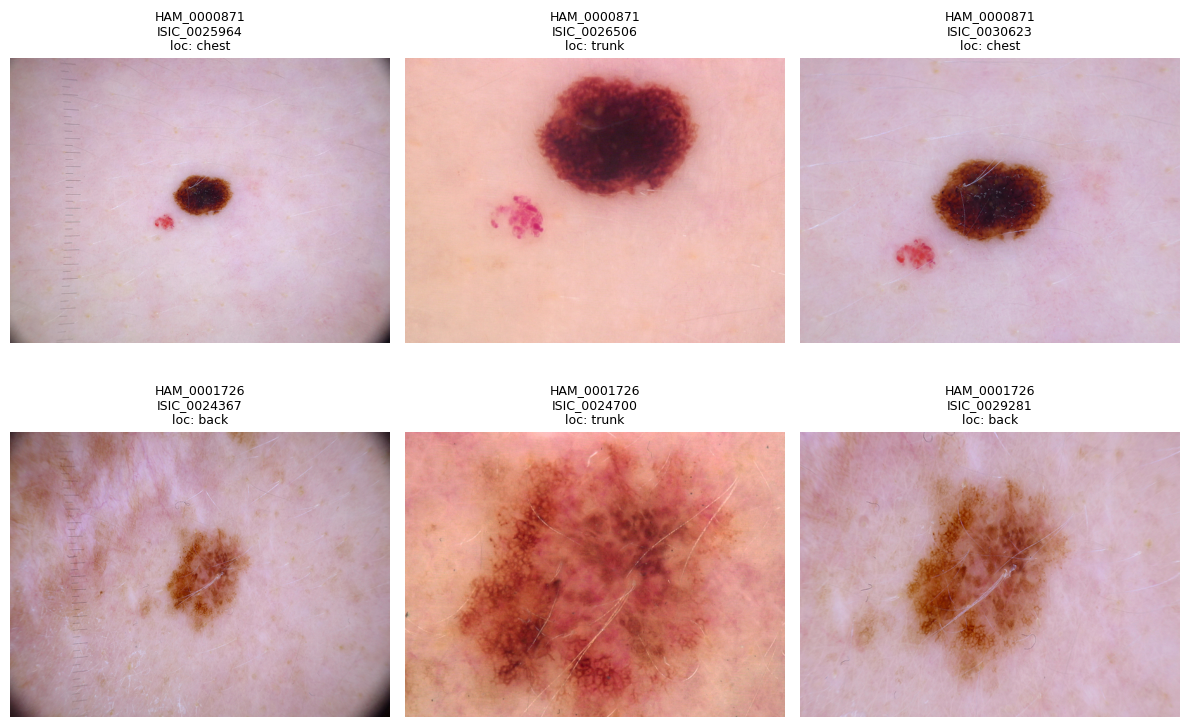

In [114]:
fig, axes = plt.subplots(len(violators), 3, figsize=(12, 4 * len(violators)))
if len(violators) == 1:
    axes = axes.reshape(1, -1)

for row, lid in enumerate(violators):
    rows = meta[meta["lesion_id"] == lid].sort_values("image_id")
    for col, (_, r) in enumerate(rows.iterrows()):
        # Find the image (lives in part_1 or part_2)
        path = next((d / f"{r['image_id']}.jpg" for d in IMG_DIRS if (d / f"{r['image_id']}.jpg").exists()), None)
        if path is None:
            axes[row, col].set_title(f"{r['image_id']}: missing")
            continue
        axes[row, col].imshow(Image.open(path))
        axes[row, col].set_title(f"{lid}\n{r['image_id']}\nloc: {r['localization']}", fontsize=9)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 7. Demographics

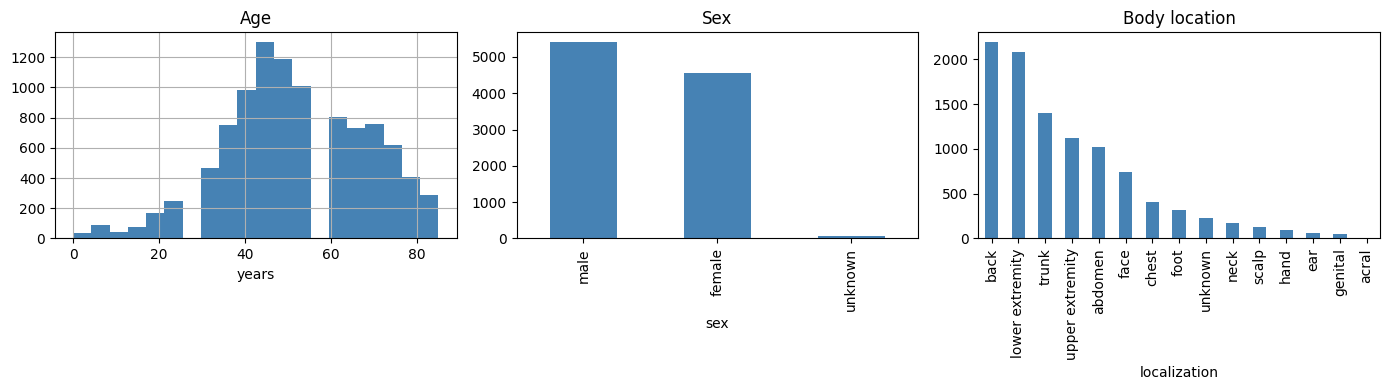

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

meta["age"].hist(ax=axes[0], bins=20, color="steelblue")
axes[0].set_title("Age")
axes[0].set_xlabel("years")

meta["sex"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Sex")

meta["localization"].value_counts().plot(kind="bar", ax=axes[2], color="steelblue")
axes[2].set_title("Body location")

plt.tight_layout()
plt.show()

## 8. Diagnosis confidence (`dx_type`)

In [116]:
print(meta["dx_type"].value_counts())
print("\ndx_type by class:")
print(pd.crosstab(meta["dx"], meta["dx_type"]))

dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

dx_type by class:
dx_type  confocal  consensus  follow_up  histo
dx                                            
akiec           0          0          0    327
bcc             0          0          0    514
bkl            69        264          0    766
df              0         60          0     55
mel             0          0          0   1113
nv              0        503       3704   2498
vasc            0         75          0     67


## 9. Sample images per class

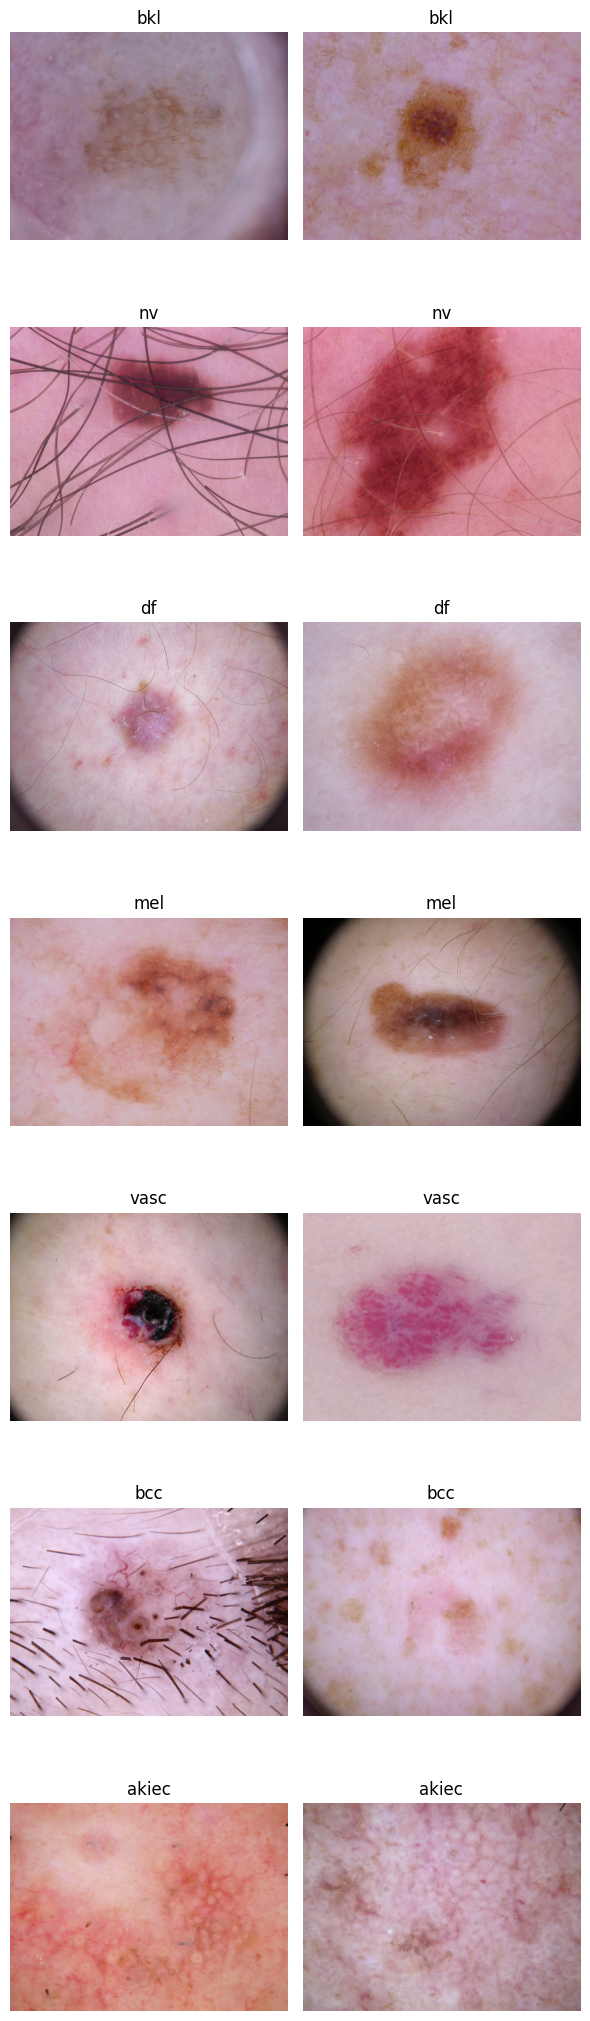

In [117]:
def find_image(image_id: str) -> Path | None:
    for d in IMG_DIRS:
        p = d / f"{image_id}.jpg"
        if p.exists():
            return p
    return None

classes = meta["dx"].unique()
samples_per_class = 2

fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 3, len(classes) * 3))

for row, dx in enumerate(classes):
    sample = meta[meta["dx"] == dx].sample(samples_per_class, random_state=0)
    for col, (_, r) in enumerate(sample.iterrows()):
        path = find_image(r["image_id"])
        if path is None:
            axes[row, col].set_title(f"{dx}: missing")
            continue
        axes[row, col].imshow(Image.open(path))
        axes[row, col].set_title(f"{dx}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### 9.1 Sample images by `dx_type`

The circular black vignette you may notice in some images is from the **dermatoscope hardware** (a contact-lens-like attachment with built-in light), not from confocal imaging. Every HAM10000 image is a dermatoscopy photo regardless of `dx_type` — the artifact shows up across all four values. Run this cell to see it for yourself: each row is one `dx_type` and you should see vignettes (or not) appearing somewhat independently of `dx_type`.

If the model picks up on these vignettes during training, it's learning a shortcut tied to the imaging device, not to the lesion itself.

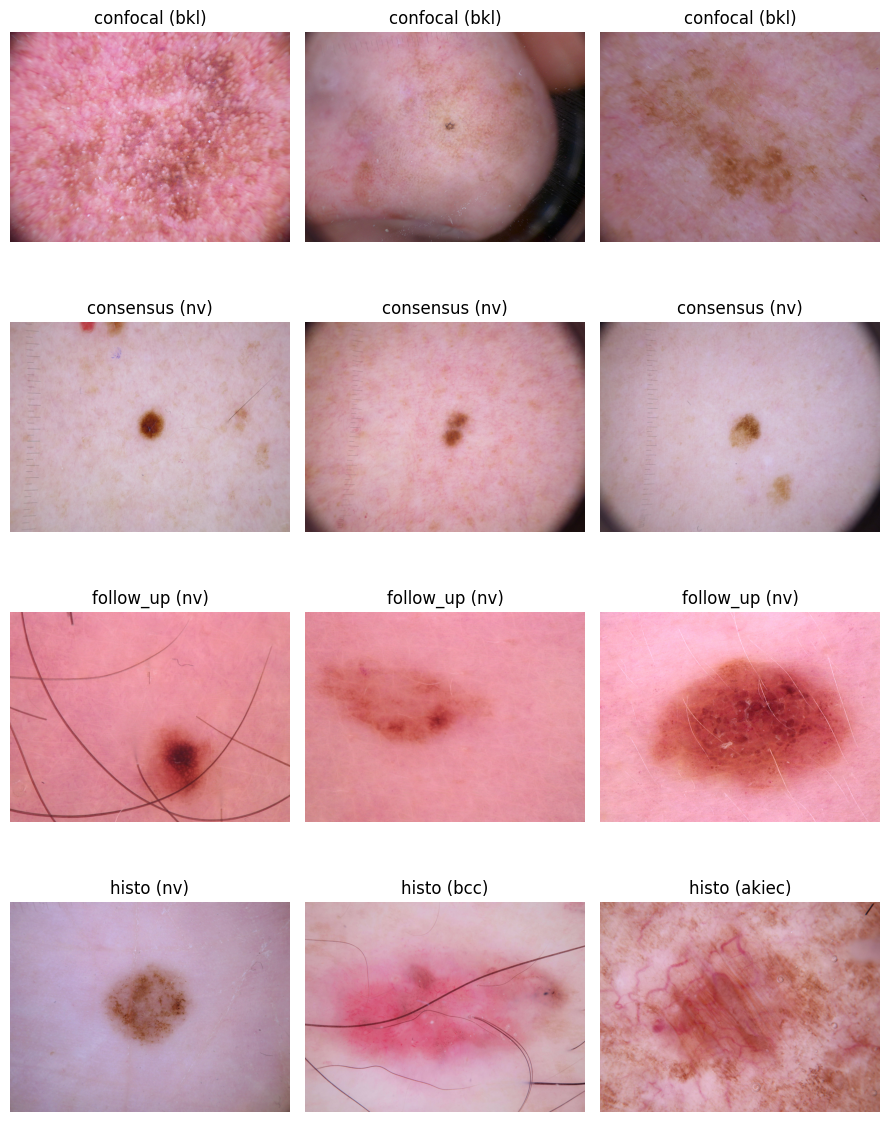

In [118]:
dx_types = sorted(meta["dx_type"].unique())
n_per_type = 3
fig, axes = plt.subplots(len(dx_types), n_per_type, figsize=(n_per_type * 3, len(dx_types) * 3))

for row, dx_type in enumerate(dx_types):
    sample = meta[meta["dx_type"] == dx_type].sample(n_per_type, random_state=1)
    for col, (_, r) in enumerate(sample.iterrows()):
        path = find_image(r["image_id"])
        if path is None:
            axes[row, col].set_title(f"{dx_type}: missing")
            continue
        axes[row, col].imshow(Image.open(path))
        axes[row, col].set_title(f"{dx_type} ({r['dx']})")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### 9.2 Mel vs nv — visual scan for rulers and artifacts

Sample 6 melanomas (top row) vs 6 nevi (bottom row). The hypothesis from the docs and the earlier observations: ruler markings, ink, and other dermatologist-added artifacts are **over-represented in malignant classes** because dermatologists place them next to suspicious lesions to track size. If true, you should see rulers visibly more often in the top row than the bottom — even though ruler-on-its-own says nothing about whether a lesion is dangerous.

This is a quick eyeball check, not a measurement. The point is to *internalize* that the model could learn rulers as a shortcut feature, which is why we'll want to look at saliency maps after training.

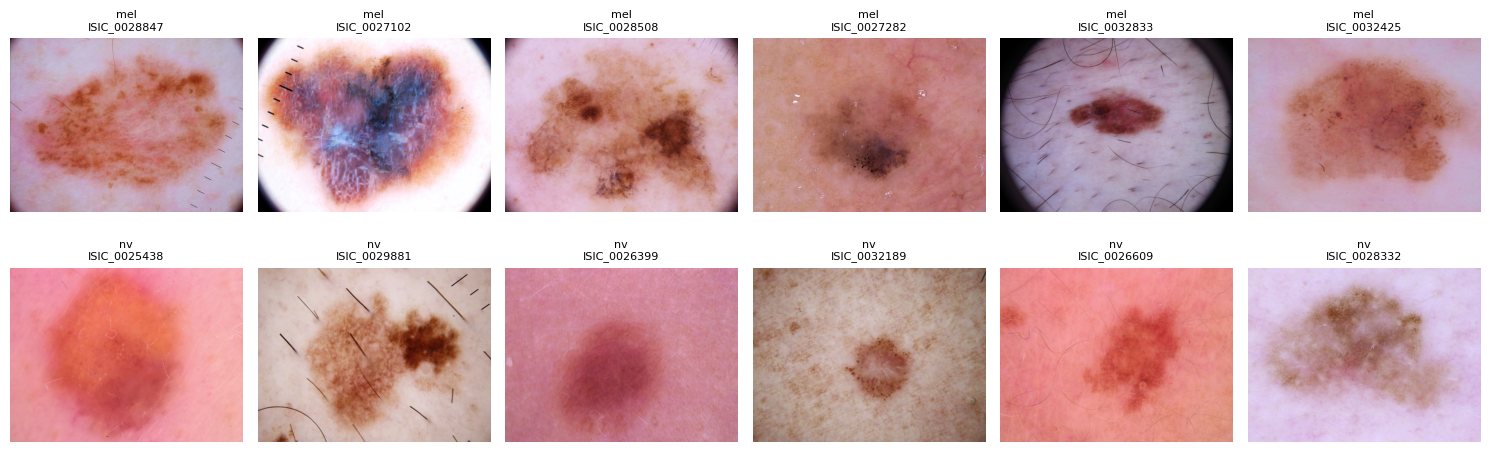

In [119]:
mel_sample = meta[meta["dx"] == "mel"].sample(6, random_state=42)
nv_sample = meta[meta["dx"] == "nv"].sample(6, random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for col, (_, r) in enumerate(mel_sample.iterrows()):
    path = find_image(r["image_id"])
    if path:
        axes[0, col].imshow(Image.open(path))
        axes[0, col].set_title(f"mel\n{r['image_id']}", fontsize=8)
        axes[0, col].axis("off")
for col, (_, r) in enumerate(nv_sample.iterrows()):
    path = find_image(r["image_id"])
    if path:
        axes[1, col].imshow(Image.open(path))
        axes[1, col].set_title(f"nv\n{r['image_id']}", fontsize=8)
        axes[1, col].axis("off")
plt.tight_layout()
plt.show()

## 10. Image dimensions sanity check

HAM10000 images are nominally 600×450. Check that nothing is corrupted or weirdly sized — anything unusual would need handling in `get_transforms()`.

In [120]:
sizes = set()
sample_ids = meta["image_id"].sample(50, random_state=0)
for image_id in sample_ids:
    path = find_image(image_id)
    if path is None:
        continue
    with Image.open(path) as img:
        sizes.add(img.size)

print("Distinct sizes in 50-image sample:", sizes)

Distinct sizes in 50-image sample: {(600, 450)}


## 11. Class distribution by body location

Where on the body does each lesion type tend to appear? This crosstab can reveal class–location correlations: melanoma is famously more common on the back and lower limbs, for instance.

localization  abdomen  acral  back  chest  ear  face  foot  genital  hand  \
dx                                                                          
akiec               5      0    29     12    3   113     0        0    13   
bcc                18      0   186     47    0   101     4        0     2   
bkl                42      0   202     74    6   319     1        2    14   
df                  4      0     2      0    0     0     2        1     0   
mel                66      0   324     68   17   104    28        0     1   
nv                860      7  1427    200   30   100   284       45    55   
vasc               27      0    22      6    0     8     0        0     5   

localization  lower extremity  neck  scalp  trunk  unknown  upper extremity  
dx                                                                           
akiec                      65    10     14      1        0               62  
bcc                        58    14     19     11        5              

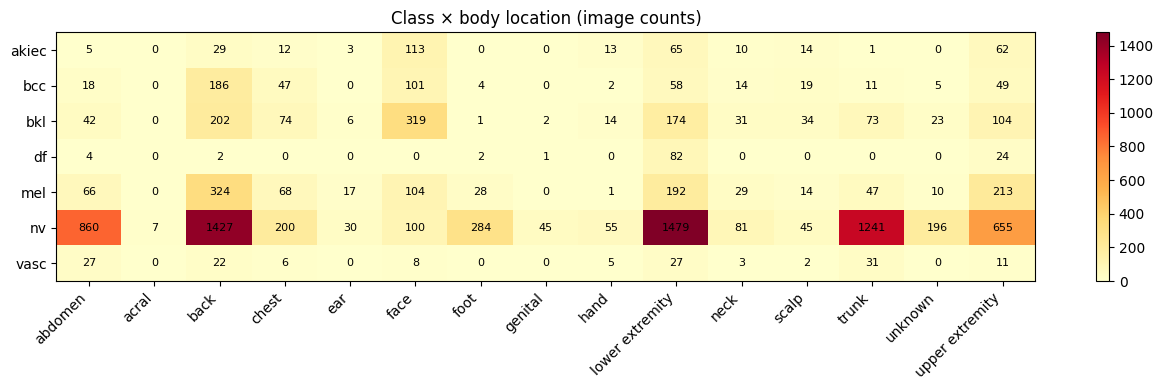

In [121]:
ct = pd.crosstab(meta["dx"], meta["localization"])
print(ct)

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(ct.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=45, ha="right")
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        ax.text(j, i, ct.values[i, j], ha="center", va="center", fontsize=8)
ax.set_title("Class \u00d7 body location (image counts)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 12. Age distribution by class

Some lesion types skew older — basal cell carcinoma and actinic keratosis are largely sun-damage related and tend to appear in older patients. Worth seeing whether age alone has signal.

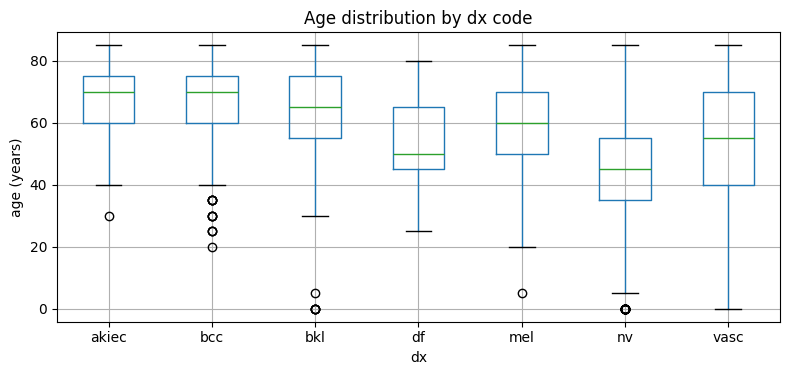


Median age by dx (descending):
dx
akiec    70.0
bcc      70.0
bkl      65.0
mel      60.0
vasc     55.0
df       50.0
nv       45.0
Name: age, dtype: float64


In [122]:
age_df = meta.dropna(subset=["age"])

fig, ax = plt.subplots(figsize=(8, 4))
age_df.boxplot(column="age", by="dx", ax=ax)
ax.set_title("Age distribution by dx code")
ax.set_xlabel("dx")
ax.set_ylabel("age (years)")
plt.suptitle("")
plt.tight_layout()
plt.show()

print("\nMedian age by dx (descending):")
print(age_df.groupby("dx")["age"].median().sort_values(ascending=False))

## 13. Image color/brightness statistics by class

Sample 20 images per class, compute the mean RGB and overall brightness. If certain classes have systematically different lighting or color (because of the camera/protocol used), that could be a confounding artifact the model learns instead of the actual lesion features.

Mean color/brightness per class (0-255):
       mean_r  mean_g  mean_b  brightness
dx                                       
akiec   197.2   144.9   149.2       163.8
bcc     199.5   157.2   161.5       172.7
bkl     172.7   136.5   146.2       151.8
df      200.5   150.8   158.3       169.9
mel     177.9   137.5   143.6       153.0
nv      203.2   144.7   153.4       167.1
vasc    200.5   150.5   163.1       171.4


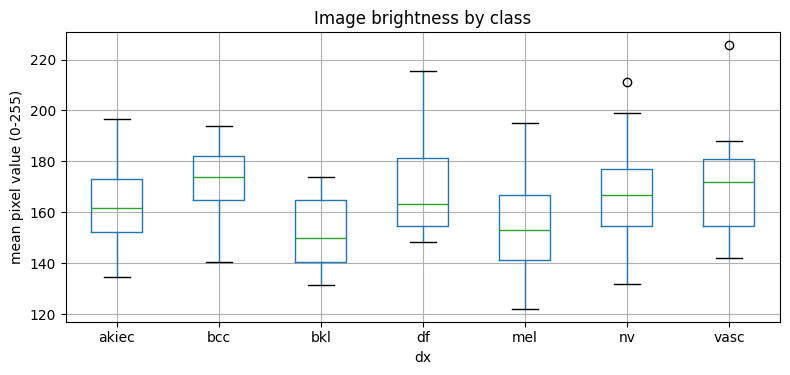

In [123]:
SAMPLES_PER_CLASS = 20

records = []
for dx, group in meta.groupby("dx"):
    sample = group.sample(min(SAMPLES_PER_CLASS, len(group)), random_state=0)
    for _, row in sample.iterrows():
        path = find_image(row["image_id"])
        if path is None:
            continue
        with Image.open(path) as img:
            arr = np.asarray(img.convert("RGB"))
            records.append({
                "dx": dx,
                "mean_r": float(arr[..., 0].mean()),
                "mean_g": float(arr[..., 1].mean()),
                "mean_b": float(arr[..., 2].mean()),
                "brightness": float(arr.mean()),
            })

color_df = pd.DataFrame(records)
print("Mean color/brightness per class (0-255):")
print(color_df.groupby("dx").mean().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
color_df.boxplot(column="brightness", by="dx", ax=ax)
ax.set_title("Image brightness by class")
ax.set_xlabel("dx")
ax.set_ylabel("mean pixel value (0-255)")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 14. Your turn

Add cells below to explore further. One angle the cells above don't cover:

- **Image quality issues you can spot by eye.** Re-run section 9 a few times with different `random_state` values and look for blurry images, hair occlusion, ruler markings, or shiny reflections. These are real artifacts in HAM10000 and the model may end up learning them as shortcuts.